In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [36]:
df = pd.read_csv("..//Dataset//spam_detection_dataset.csv")

In [37]:
df.head()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


In [38]:
df.sample(5)

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
19635,0,195,1,0.748511,0,0
3946,1,47,0,0.610152,0,0
14538,0,189,1,0.549474,0,0
19329,0,174,0,0.408959,0,0
1059,0,54,0,0.508685,0,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [40]:
df.describe()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,1.497300,109.506150,0.302750,0.694248,0.097800,0.09175
std,1.220478,51.969579,0.459459,0.188312,0.297051,0.28868
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,64.000000,0.000000,0.567073,0.000000,0.00000
50%,1.000000,110.000000,0.000000,0.699740,0.000000,0.00000
75%,2.000000,154.000000,1.000000,0.834083,0.000000,0.00000
max,9.000000,199.000000,1.000000,1.000000,1.000000,1.00000


In [41]:
df.shape

(20000, 6)

In [42]:
df.isnull().sum()

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

In [43]:
df.duplicated().sum()

402

In [44]:
df.drop_duplicates(inplace=True)

In [45]:
df.shape

(19598, 6)

<Axes: xlabel='is_spam', ylabel='num_words'>

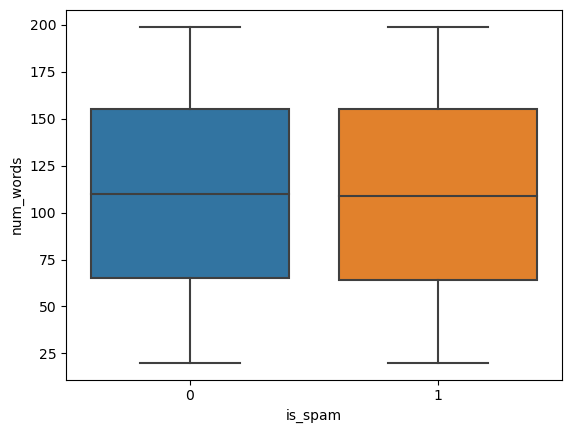

In [46]:
sns.boxplot(x='is_spam', y='num_words', data=df)


<Axes: xlabel='has_offer', ylabel='count'>

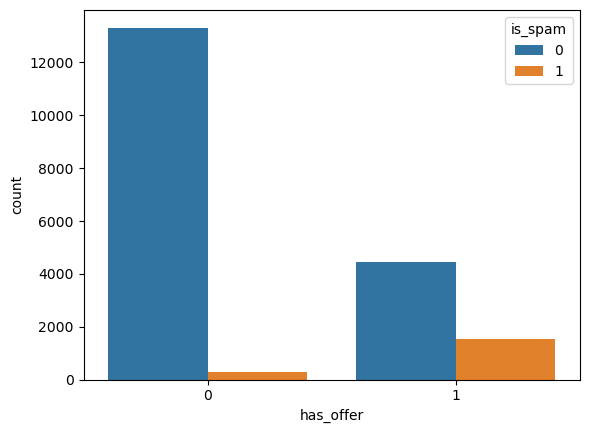

In [47]:
sns.countplot(x='has_offer', hue='is_spam', data=df)

<Axes: xlabel='all_caps', ylabel='count'>

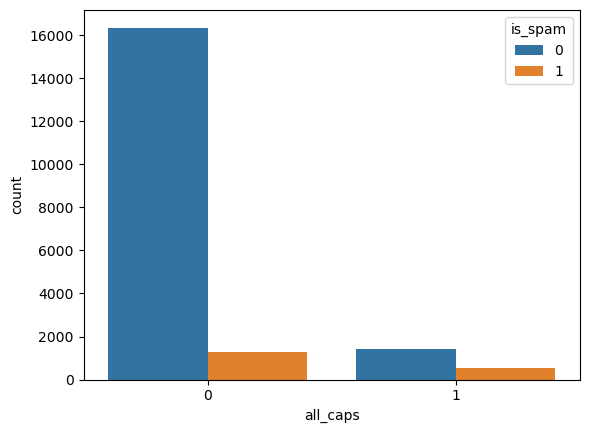

In [48]:
sns.countplot(x='all_caps', hue='is_spam', data=df)

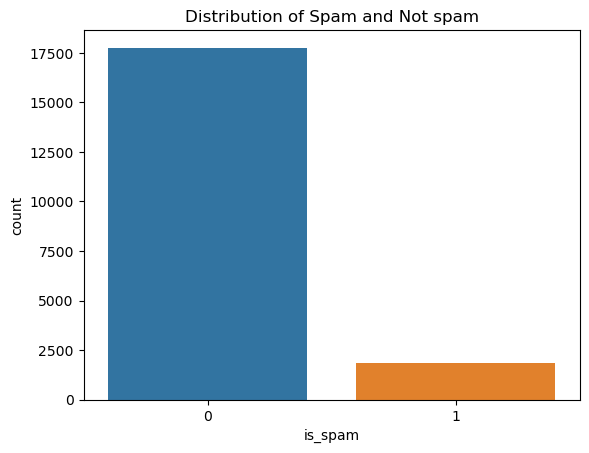

In [49]:
sns.countplot(x="is_spam", data=df)
plt.title("Distribution of Spam and Not spam")
plt.show()

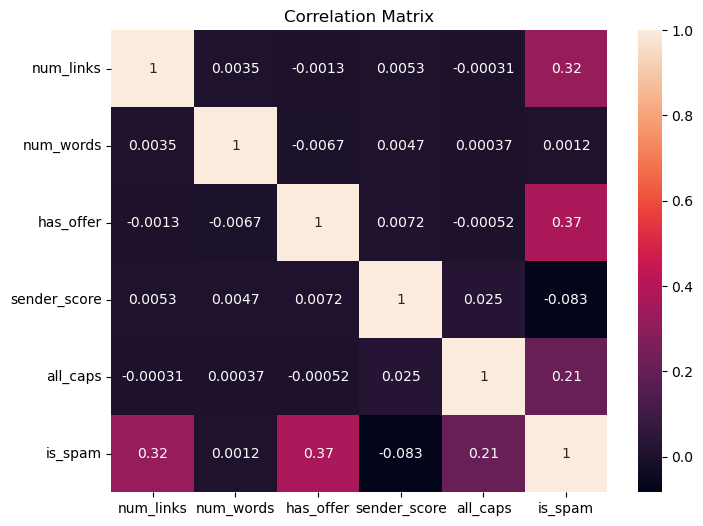

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

### Data preprocessing


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['num_links', 'num_words', 'sender_score']] = scaler.fit_transform(df[['num_links', 'num_words', 'sender_score']])


In [52]:
df

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,1.221159,-0.222142,1,0.165557,0,0
1,-1.227657,1.161949,0,0.059048,1,0
2,-1.227657,-1.375552,0,-0.364897,0,0
3,-1.227657,0.123881,0,0.074470,0,0
4,1.221159,-0.395154,1,-0.564041,1,1
...,...,...,...,...,...,...
19995,-0.411385,-1.683128,1,-0.396866,0,0
19996,1.221159,0.854373,0,1.686486,1,1
19997,2.037431,-0.010684,0,1.339743,1,0
19998,0.404887,1.680983,0,-1.114536,0,0


In [53]:
X = df.drop('is_spam', axis=1)
y = df['is_spam']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, lambda_reg=0.01):
        self.lr = learning_rate
        self.n_iters = n_iterations
        self.lambda_reg = lambda_reg
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def compute_bce_loss(self, y_true, y_pred):
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred + epsilon)
        y2 = (1 - y_true) * np.log(1 - y_pred + epsilon)
        return -np.mean(y1 + y2)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_pred = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear_pred)
            
            l2_loss = (self.lambda_reg / (2 * n_samples)) * np.sum(self.weights ** 2)
            self.losses.append(self.compute_bce_loss(y, predictions) + l2_loss)
            
            dw = (1 / n_samples) * (np.dot(X.T, (predictions - y)) + self.lambda_reg * self.weights)
            db = (1 / n_samples) * np.sum(predictions - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_pred)
        return (y_pred >= 0.5).astype(int)

In [56]:
custom_model = CustomLogisticRegression(learning_rate=0.01, n_iterations=1000)
custom_model.fit(X_train, y_train)

In [57]:
# Make predictions
y_pred = custom_model.predict(X_test)

In [58]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [59]:
# Print the classification report
print("Classification Report for Custom Logistic Regression:")
print(classification_report(y_test, y_pred))

Classification Report for Custom Logistic Regression:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      3540
           1       0.50      0.01      0.02       380

    accuracy                           0.90      3920
   macro avg       0.70      0.50      0.48      3920
weighted avg       0.86      0.90      0.86      3920



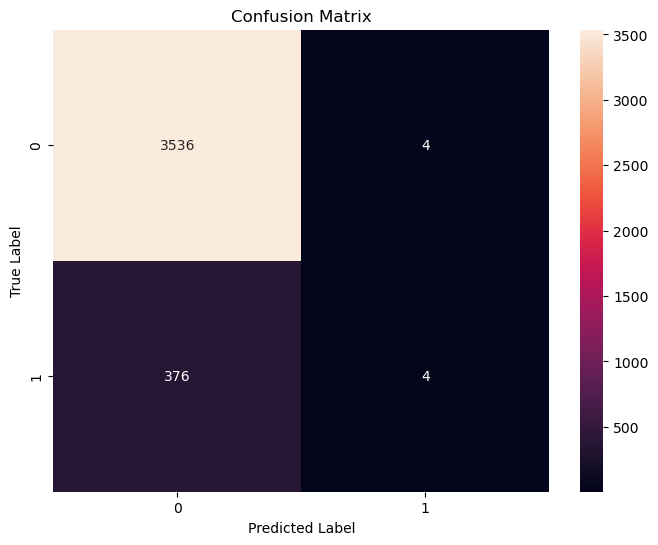

In [60]:
# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Visualize Training Loss

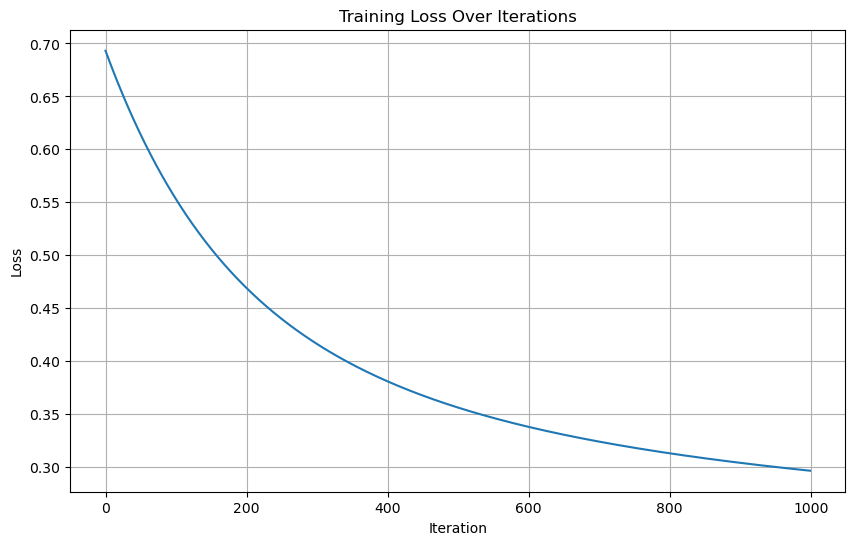

In [61]:
# Plot the training loss
plt.figure(figsize=(10,6))
plt.plot(custom_model.losses)
plt.title('Training Loss Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [62]:
# Train sklearn model
sklearn_model = LogisticRegression(random_state=40, max_iter=1000)
sklearn_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=40)

In [63]:
sklearn_prediction = sklearn_model.predict(X_test)
sklearn_probs = sklearn_model.predict_proba(X_test)[:, 1]

In [64]:
print("Classification Report for Sklearn Logistic Regression:")
print(classification_report(y_test, sklearn_prediction))

Classification Report for Sklearn Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      3540
           1       0.81      0.52      0.63       380

    accuracy                           0.94      3920
   macro avg       0.88      0.75      0.80      3920
weighted avg       0.94      0.94      0.94      3920



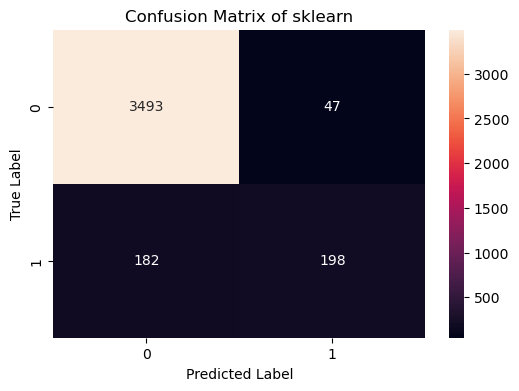

In [65]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, sklearn_prediction), annot=True, fmt='d')
plt.title('Confusion Matrix of sklearn')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Calculate ROC curves

In [69]:
custom_model_probs = custom_model.sigmoid(np.dot(X_test, custom_model.weights) + custom_model.bias)
fpr_custom_model, tpr_custom_model, _ = roc_curve(y_test, custom_model_probs)
fpr_sklearn_model, tpr_sklearn_model, _ = roc_curve(y_test, sklearn_probs)

### Calculate AUC


In [70]:
auc_custom_model = auc(fpr_custom_model, tpr_custom_model)
auc_sklearn_model = auc(fpr_sklearn_model, tpr_sklearn_model)

### Plot ROC curves


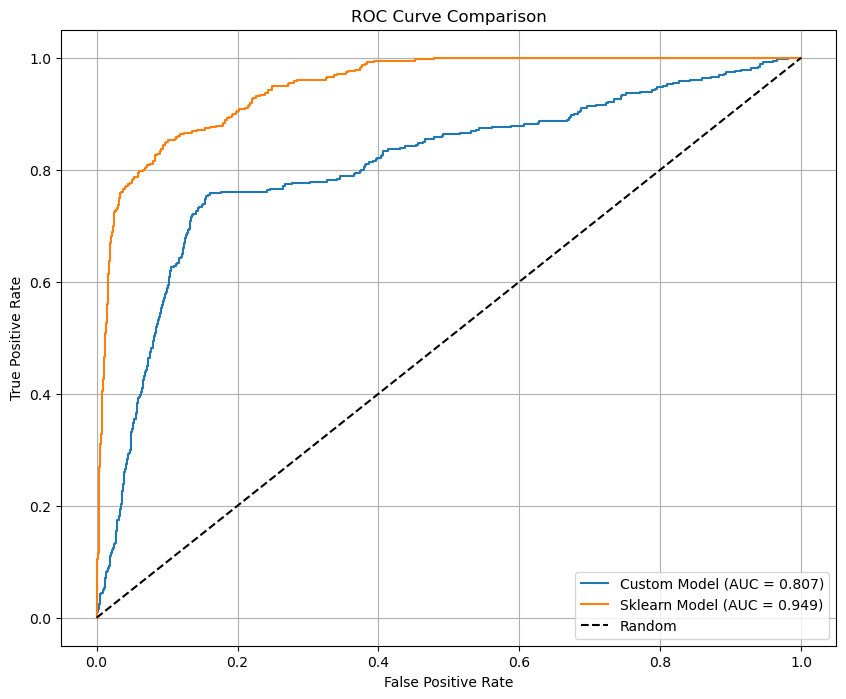

In [71]:
plt.figure(figsize=(10, 8))
plt.plot(fpr_custom_model, tpr_custom_model, label=f'Custom Model (AUC = {auc_custom_model:.3f})')
plt.plot(fpr_sklearn_model, tpr_sklearn_model, label=f'Sklearn Model (AUC = {auc_sklearn_model:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

### What is the ROC Curve?
=> The ROC (Receiver Operating Characteristic) curve shows the trade-off between True Positive Rate (Sensitivity) and False Positive Rate.

=> The closer the curve is to the top-left corner, the better the model.

=> The dashed line represents a random guess model (AUC = 0.5), which is the baseline.

#### Analysis of Your ROC Curve

Custom Model:	AUC Score=0.705	 Meaning= Performs well, better than random, but can be improved.

Sklearn Model:	AUC Score=0.949	 Meaning= Performs very well, close to perfect.

Random Model:	AUC Score=0.5	Just for reference – a coin toss level performance.

### 4. Why is Accuracy Not Always a Suitable Evaluation Metric?

**Accuracy** is the ratio of correctly predicted(TP+TN) observations to the total observations(TP+TN+FP+FN):


While accuracy is easy to understand, it **may not be reliable in all situations**, especially when the data is **imbalanced**.

---

#### Example:
Suppose we have a dataset for spam detection(like above dataset):
- 95% emails are **not spam**
- 5% emails are **spam**

If a model predicts **everything as not spam**, it will be **95% accurate**, but it's actually **useless** because it never detects any spam.

---

#### Problems with Accuracy:
- **Misleading in Imbalanced Data**: In cases where one class is much more frequent, accuracy can be high even if the model is performing poorly on the minority class.
- **Ignores Type of Errors**: Accuracy does not tell us if the model is making more **false positives** or **false negatives**, which might be important in many real-world problems.

---

#### Better Alternatives:
- **Precision** – how many predicted positives are actually correct?
- **Recall** – how many actual positives did the model find?
- **F1 Score** – balance between precision and recall.
- **ROC-AUC** – performance across different thresholds.



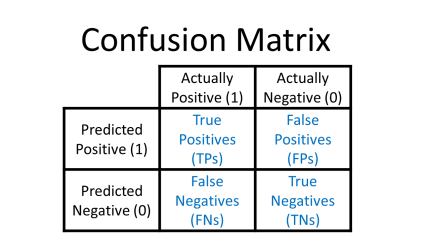

## 5. When to Choose Precision Over Recall and Vice-Versa?

#### Meaning

**Precision** = Out of all predicted positive, how many were actually positive?  (TP)/(TP+FP)  

**Recall** = Out of all actual positive, how many did we correctly predict?   (TP)/(TP+FN)  

---

###  Choose **Precision** When:
You want to **be sure that what you predicted as positive is really positive**.

####  Example: Spam Detection
- If you mark an email as spam, it should really be spam.
- Otherwise, important emails like job offers or college updates might go to spam.

So, **high precision** is important.

---

###  Choose **Recall** When:
You want to **catch as many actual positive cases as possible**, even if a few are wrong.

####  Example: Cancer Detection
- You want to catch **all people with cancer**, even if some healthy people are wrongly tested positive.
- Missing a cancer case (false negative) is risky.

So, **high recall** is important.


